# Linear regression model

This project focuses on supervised learning, particularly linear models, regularization techniques, overfitting, underfitting, and metrics for quality estimation.

**Data:** [Two Sigma Connect: Rental Listing Inquiries](https://www.kaggle.com/competitions/two-sigma-connect-rental-listing-inquiries/data)
(`train.json`, apartment rental listings, renthop.com).

**Goal**: predict `price` with a self-implemented regression model and compare its performance against `sklearn`.

**Notebook structure**
| Section | Content |
|--------|------------|
| 0. [Imports and functions](#0-imports-and-functions) | Libraries and helper functions |
| 1. [Theoretical part](#1-theoretical-part) | Analytical solution, L1/L2, non linear relationships |
| 2. [Data Preprocessing & Analysis](#2-data-preprocessing--analysis) | dropping outliers, cleaning, building new features; train/test split |
| 3. [Linear regression from scratch](#3-models-implementation--linear-regression) | SGD, GD & analytical methods; metrics; comparison with sklearn |
| 5. Регуляризация | свои Ridge, Lasso, ElasticNet |
| 6. Нормализация | свои MinMaxScaler и StandardScaler |
| 7. Обучение на нормализованных | все модели × 2 скейлера |
| 8. Переобучение | полиномы degree=10, подбор alpha |
| 9. Наивные модели | mean и median |
| 10. Сравнение | лучшая и самая устойчивая модель |
| 11. Дополнительно | log-таргет, выбросы, mini-batch |

## 0. Imports and functions

In [28]:
#standard libraries
import re
import time
from collections import Counter

# data processing
import pandas as pd
import numpy as np

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning (for comparison)
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


RANDOM_STATE = 21 # deterministic results

print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
print("scikit-learn", sklearn.__version__)

numpy        2.5.3
pandas       3.0.5
scikit-learn 1.9.1


Q. Define the R squared (R2) coefficient and implement a function to calculate it.

$$
R^2 = 1 - \frac{\sum_i(y_i-\hat{y}_i)^2}{\sum_i(y_i-\bar{y})^2}
$$

$R^2$ measures the **proportion of variance in the target variable that is explained by the model**, relative to a naive baseline that always predicts the mean $\bar{y}$.

- $R^2 = 1$: perfect predictions
- $R^2 = 0$: the model performs no better than the naive model.

Why $R^2$ is more convenient than MAE and RMSE: it is dimensionless. An MAE of $700 says nothing on its own, whereas $R^2$ = 0.59 immediately reads as "we explained 59 % of the price variance."

In [29]:
def r2_score_custom(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

Results tables for metrics

In [30]:
result_MAE = pd.DataFrame(columns=["model", "train", "test"])
result_RMSE = pd.DataFrame(columns=["model", "train", "test"])
result_R2 = pd.DataFrame(columns=["model", "train", "test"])


def add_result(name, y_tr, p_tr, y_te, p_te):
    result_MAE.loc[len(result_MAE)] = [name, mean_absolute_error(y_tr, p_tr),
                                       mean_absolute_error(y_te, p_te)]
    result_RMSE.loc[len(result_RMSE)] = [name, root_mean_squared_error(y_tr, p_tr), root_mean_squared_error(y_te, p_te)]
    result_R2.loc[len(result_R2)] = [name, r2_score_custom(y_tr, p_tr), r2_score_custom(y_te, p_te)]
    print(f"{name:<36} MAE {mean_absolute_error(y_tr, p_tr):8.2f} / {mean_absolute_error(y_te, p_te):8.2f}"
          f"   RMSE {root_mean_squared_error(y_tr, p_tr):8.2f} / {root_mean_squared_error(y_te, p_te):8.2f}"
          f"   R2 {r2_score_custom(y_tr, p_tr):7.4f} / {r2_score_custom(y_te, p_te):7.4f}")

def compare(name_a, pred_a, name_b, pred_b, y_true):
    ma, mb = mean_absolute_error(y_true, pred_a), mean_absolute_error(y_true, pred_b)
    print(f"  {name_a:<22} MAE {ma:8.2f}   RMSE {root_mean_squared_error(y_true, pred_a):8.2f}   R2 {r2_score_custom(y_true, pred_a):7.4f}")
    print(f"  {name_b:<22} MAE {mb:8.2f}   RMSE {root_mean_squared_error(y_true, pred_b):8.2f}   R2 {r2_score_custom(y_true, pred_b):7.4f}")
    print(f"  MAE difference: {abs(ma - mb):.2f} $  ({abs(ma - mb) / mb * 100:.2f} %)")

## 1. Theoretical part

### 1.1. Derive an analytical solution to the regression problem. Use a vector form of the equation.

**Setting.** Feature matrix $X \in \mathbb{R}^{n \times d}$, target vector
$y \in \mathbb{R}^{n}$, weight vector $w \in \mathbb{R}^{d}$.

**Linear regression** model prediction:

$$
\hat{y} = Xw
$$

**Loss function** (MSE) in vector form:

$$
L(w) = \frac{1}{N}\|Xw-y\|_2^2
= \frac{1}{N}(Xw-y)^T(Xw-y)
$$

Expanding the parentheses:

$$
\begin{aligned}
(Xw-y)^T(Xw-y)
&= w^T X^T X w - w^T X^T y - y^T Xw + y^T y \\
&= w^T X^T X w - 2w^T X^T y + y^T y
\end{aligned}
$$

Taking the **gradient** with respect to $w$ and setting it to zero:

$$
\nabla_w L(w)
= 2X^T Xw - 2X^T y = 0 \qquad \text{(Normal equation)}
$$

Therefore,

$$
X^T Xw = X^T y
$$

and, assuming $X^T X$ is invertible,

$$
\boxed{w = (X^T X)^{-1}X^T y}
$$

**Minimum check.** The Hessian is $2X^⊤X⪰0$ so $L$ is convex;
therefore the stationary point is a global minimum.

**Limitations.** The matrix $X^TX$ is not invertible if:
* The features are linearly dependent;
* There are more features than samples ( $\operatorname{rank} X \leq n < d$ )

In these cases there are infinitely many solutions. A practical workaround is
the **Moore–Penrose pseudoinverse** (np.linalg.pinv) or **regularization**.

**Computational cost.** Inverting the matrix costs $O(d^3)$, and forming $X^T X$ costs $O(nd^2)$. For large $d$ this is expensive, so in practice gradient descent is used more often.

### 1.2. What changes in the solution when L1 and L2 regularizations are added to the loss function.

#### L2 (Ridge)

Loss function with **L2 penalty**:

$$
L(w) = (Xw-y)^T(Xw-y) + \lambda w^Tw
$$

Taking the gradient with respect to $w$:

$$
\nabla_w L(w) = 2X^TXw - 2X^Ty + 2\lambda w = 0
$$

$$
(X^TX + \lambda I)w = X^Ty
$$

$$
\boxed{w = (X^TX + \lambda I)^{-1}X^Ty}
$$

Unlike the unregularized case, $X^TX + \lambda I$ is **invertible** for any $\lambda > 0$, even when $X^TX$ itself is singular.

#### L1 regularization (Lasso)

Loss function with **L1 penalty**:

$$
L(w) = (Xw-y)^T(Xw-y) + \lambda \|w\|_1
$$

The L1 term $\|w\|_1 = \sum_i |w_i|$ is not differentiable at $w_i = 0$, so no closed-form analytical solution exists. The optimum must be found with **iterative methods**.

### 1.3. Explain why L1 regularization is often used to select features. Why are there many weights equal to 0 after the model is fit?

Geometrically, the constraint region $\|w\|_1 \le c$ (L1) is a diamond with corners lying exactly on the coordinate axes,  at points where one of the coordinates is zero. The constraint region $\|w\|_2 \le c$ (L2) is a smooth circle.

The **regularized solution** is the point where the loss function's ellipses first touch the constraint region's boundary.

- In L1 diamond, a single point on a flat side only accepts one specific angle of the ellipse. A sharp corner can catch an ellipse coming from a wide range of different angles, so ellipse is geometrically much **more likely** to bump into a sharp corner first than to hit one of the flat sides.

- On a smooth L2 circle, every boundary point has one single, fixed normal direction, so there is **no special point** at which contact is more likely — both coordinates typically remain nonzero.

Since the corners of the L1 diamond correspond to points where one or more weights equal zero, many features with zero weights are excluded, achieving automatic **feature selection**.

### 1.4. Explain how you can use the same models (Linear regression, Ridge, etc.) but make it possible to fit nonlinear dependencies.

The trick is to keep the model linear in the weights $w$, but apply a **nonlinear transformation $\phi$** to the original features before fitting:

$$
\hat{y} = w^T\phi(x)
$$

For example, for a single feature $x$, we can construct polynomial features:

$$
\phi(x) = [1, x, x^2, x^3, \dots]
$$

so that:

$$
\hat{y} = w_0 + w_1x + w_2x^2 + w_3x^3 + \dots
$$

This expression is linear in the weights $w_i$, but **nonlinear in the original feature** $x$. Because linear regression, Ridge, Lasso, etc. only require linearity in $w$, the same algorithms can be applied directly to $\phi(x)$ instead of $x$, allowing them to fit nonlinear dependencies without any change to the underlying method.

## 2. Data Preprocessing & Analysis

1. Read `train.json`;
2. Remove ourliers — discard prices outside the 1st and 99th percentiles;
3. Split the data into training and test sets in an 80/20 ratio;

In [31]:
data = pd.read_json('data/train.json')

low = data['price'].quantile(0.01)
high = data['price'].quantile(0.99)
data = data[(data['price'] >= low) & (data['price'] <= high)]

data.head(3)

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0000,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0000,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0000,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium


4. Build features from the features column — a list of the apartment's amenities

In [32]:
print("Examples of features column values:\n")
for v in data["features"].head(5):
    print(" ", v)

print(f"\nEmpty lists: {(data['features'].apply(len) == 0).sum()} "
      f"({(data['features'].apply(len) == 0).mean():.1%})")
print(f"Average number of amenities per listing: {data['features'].apply(len).mean():.2f}")

Examples of features column values:

  ['Dining Room', 'Pre-War', 'Laundry in Building', 'Dishwasher', 'Hardwood Floors', 'Dogs Allowed', 'Cats Allowed']
  ['Doorman', 'Elevator', 'Laundry in Building', 'Dishwasher', 'Hardwood Floors', 'No Fee']
  ['Doorman', 'Elevator', 'Laundry in Building', 'Laundry in Unit', 'Dishwasher', 'Hardwood Floors']
  []
  ['Doorman', 'Elevator', 'Fitness Center', 'Laundry in Building']

Empty lists: 3109 (6.4%)
Average number of amenities per listing: 5.43


Remove extra characters `[`, `]`, `'`, `"`, and spaces

In [33]:
def clean_features(feature_list):
    return [re.sub(r"[\[\]'\"]", "", f).strip() for f in feature_list]

data['features_clean'] = data['features'].apply(clean_features)

Combine all values into a single list

In [34]:
all_features = []
for feature_list in data['features_clean']:
    all_features.extend(feature_list)

Get top-20 most common features

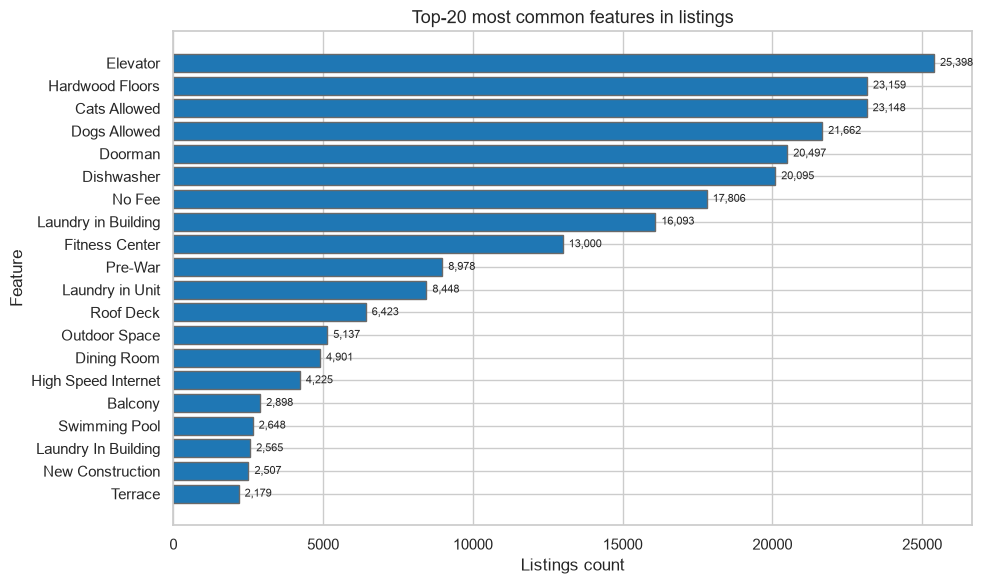

In [63]:
counter = Counter(all_features)
top_20 = [item for item, count in counter.most_common(20)]

fig, ax = plt.subplots(figsize=(10, 6))
names = [n for n, _ in counter.most_common(20)][::-1]
values = [c for _, c in counter.most_common(20)][::-1]

ax.barh(names, values, color="tab:blue", edgecolor="dimgray")
ax.set_title("Top-20 most common features in listings")
ax.set_xlabel("Listings count")
ax.set_ylabel("Feature")

for i, v in enumerate(values):
    ax.text(v + 200, i, f"{v:,}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

Build 20 new binary features and add bathrooms, bedrooms

In [36]:
df = data[['price', 'bathrooms', 'bedrooms']].copy()

for feat in top_20:
    df[feat] = data['features_clean'].apply(lambda lst: 1 if feat in lst else 0)

feature_list = top_20 + ['bathrooms', 'bedrooms']

X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

Check correlation of each feature with price

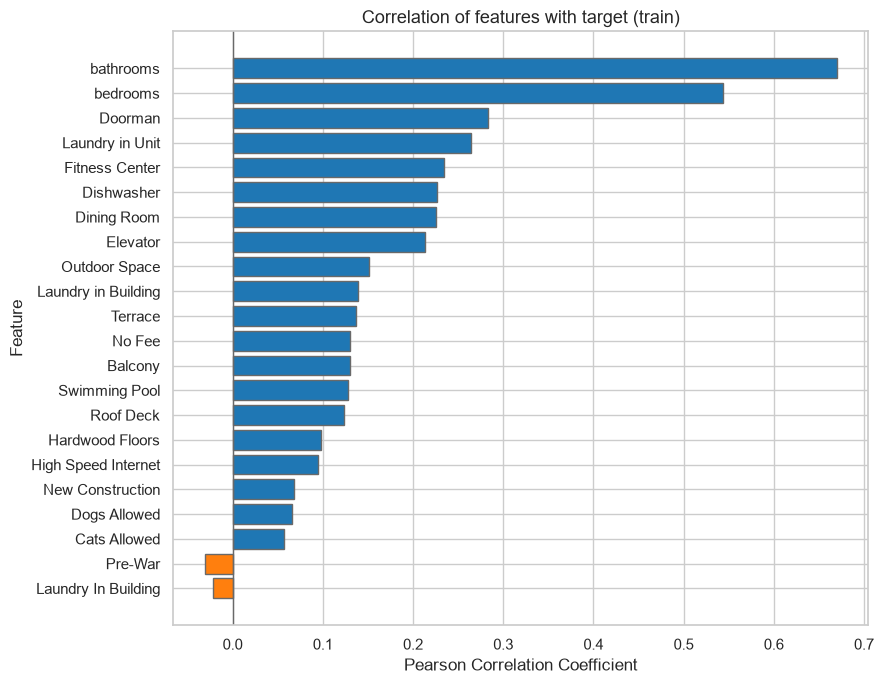

bathrooms              0.6697
bedrooms               0.5435
Doorman                0.2831
Laundry in Unit        0.2638
Fitness Center         0.2339
Dishwasher             0.2261
Dining Room            0.2251
Elevator               0.2136
Outdoor Space          0.1514
Laundry in Building    0.1387
Terrace                0.1365
No Fee                 0.1306
Balcony                0.1305
Swimming Pool          0.1274
Roof Deck              0.1235
Hardwood Floors        0.0978
High Speed Internet    0.0947
New Construction       0.0678
Dogs Allowed           0.0655
Cats Allowed           0.0568
Pre-War               -0.0307
Laundry In Building   -0.0222


In [62]:
corr_with_target = (X_train.assign(price=y_train).corr()["price"]
                    .drop("price").sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["tab:blue" if v > 0 else "tab:orange" for v in corr_with_target.values[::-1]]
ax.barh(corr_with_target.index[::-1], corr_with_target.values[::-1],
        color=colors, edgecolor="dimgray")
ax.axvline(0, color="dimgray", lw=1)
ax.set_title("Correlation of features with target (train)")
ax.set_xlabel("Pearson Correlation Coefficient")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

print(corr_with_target.to_string())

What we can see:

* Price is most strongly correlated with `bathrooms` **(0.67)** and `bedrooms` **(0.55)**;

* Among the amenities, `Doorman` **(0.28)** performs best — doorman buildings tend to be
expensive; it is followed by `Dishwasher`, `Elevator`, `FitnessCenter`, and `SwimmingPool`;

* `NoFee` and `Pre-War` are **negatively correlated** — "no fee" is more common in the
cheaper segment, while pre-war buildings are on average cheaper than new builds;

* Most amenities are weak on their own (|r| < 0.15), but together they give the model
a noticeable improvement. Previously we only considered `bathrooms` and `bedrooms` (MAE $754); we now add features and compare.

## 3. Models implementation — Linear regression

### 3.1. Custom LinearRegression

A single class with 3 solvers:
| `solver` | Description | Pros |
|---|---|---|
| `"analytic"` | Normal equation $\hat w = (X^TX)^{-1}X^Ty$ | exact solution (used when few features) |
| `"gd"` | Batch gradient descent | stable |
| `"sgd"` | Stochastic gradient descent | fast |


`batch_size` turns `sgd` into mini-batch

**MSE gradient** with respect to the weight vector:
$$\nabla_w \text{MSE} = \frac{2}{m} X_b^T (X_b w - y_b)$$
where $X_b$ is the current batch of $m$ samples.

**Regularization** is added here as well, so that the code is not duplicated in Section 4.
The penalty formulas are chosen so that the **same loss function is minimized
as in `sklearn`** — otherwise the metrics will not match (details in Section 4).



In [38]:
class CustomLinearRegression:
    '''Linear regression with multiple solvers: analytical solution, GD, SGD and mini-batch.
    
        penalty : None | 'l2' | 'l1' | 'elastic'  — regularization type
        alpha   : strength of regularization (like alpha in sklearn)
        solver  : 'sgd' | 'gd' | 'analytic'

        Combined with batch_size 'sgd' covers both pure SGD and mini-batch:

          * batch_size=1   → pure SGD,
          * 1 < batch_size < n_samples → mini-batch,
          * batch_size=n_samples → equivalent to full-batch GD.

        '''
    def __init__(self, learning_rate=1e-5, n_epochs=30, batch_size=1,
                 solver='sgd', penalty=None, alpha=1.0, l1_ratio=0.5,
                 fit_intercept=True, random_state=RANDOM_STATE):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.solver = solver
        self.penalty = penalty
        self.alpha = alpha
        self.l1_ratio = l1_ratio
        self.fit_intercept = fit_intercept
        self.random_state = random_state

    def _add_bias(self, X):
        X = np.asarray(X, dtype=float)
        if not self.fit_intercept:
            return X
        return np.c_[np.ones((X.shape[0], 1)), X]

    def _penalty_grad(self, w, n_samples):
            '''Gradient of the regularization term. The intercept is not penalized.'''
            grad = np.zeros_like(w)
            start = 1 if self.fit_intercept else 0
            if self.penalty == "l2":
                # sklearn Ridge minimizes ||y-Xw||^2 + alpha*||w||^2,
                # to get the same minimum, we scale by alpha/n
                grad[start:] = 2 * self.alpha / n_samples * w[start:]
            elif self.penalty == "l1":
                # sklearn Lasso minimizes (1/2n)||y-Xw||^2 + alpha*||w||_1
                grad[start:] = 2 * self.alpha * np.sign(w[start:])
            elif self.penalty == "elastic":
                # sklearn ElasticNet minimizes (1/2n)||y-Xw||^2 + alpha*(l1_ratio*||w||_1 + 0.5 * (1-l1_ratio)*||w||^2)
                grad[start:] = 2 * self.alpha * (self.l1_ratio * np.sign(w[start:])
                                                  + (1 - self.l1_ratio) * w[start:])
            return grad
    

    def fit(self, X, y):
        X = self._add_bias(X)
        y = np.asarray(y, dtype=float)
        n_samples, n_features = X.shape

        if self.solver == "analytic":
            self.weights_ = np.linalg.pinv(X.T @ X) @ X.T @ y
            self.loss_history_ = []
            return self
        
        batch = n_samples if self.solver == "gd" else self.batch_size
        rng = np.random.default_rng(self.random_state)
        w = np.zeros(n_features)
        self.loss_history_ = []

        for _ in range(self.n_epochs):
            indices = rng.permutation(n_samples)
            for start in range(0, n_samples, batch):
                idx = indices[start:start + batch]
                xi = X[idx]
                yi = y[idx]
                grad = 2 * xi.T @ (xi @ w - yi) / len(idx)
                w -= self.learning_rate * (grad + self._penalty_grad(w, n_samples))
            self.loss_history_.append(np.mean((X @ w - y) ** 2))

        self.weights_ = w
        return self

    def predict(self, X):
        X = self._add_bias(X)
        return X @ self.weights_

    # Compatibility with sklearn
    @property
    def intercept_(self):
        return self.weights_[0] if self.fit_intercept else 0.0
    
    @property
    def coef_(self):
        return self.weights_[1:] if self.fit_intercept else self.weights_

### 3.2. Training custom implementations and computing MAE, RMSE, R²

We compare the three training methods against each other.

In [39]:
"""
GD makes one parameter update per epoch,
so we use more epochs than for SGD
"""
models_own = {}
for solver, params in [("analytic", {}),
                       ("gd", dict(learning_rate=1e-2, n_epochs=2000)),
                       ("sgd", dict(learning_rate=1e-5, n_epochs=30))]:
    t0 = time.time()
    model = CustomLinearRegression(solver=solver, **params).fit(X_train, y_train)
    elapsed = time.time() - t0
    models_own[solver] = model
    p_tr, p_te = model.predict(X_train), model.predict(X_test)
    print(f"{solver:<9} ({elapsed:5.2f} с)  MAE {mean_absolute_error(y_train, p_tr):7.2f} / "
          f"{mean_absolute_error(y_test, p_te):7.2f}   RMSE {root_mean_squared_error(y_train, p_tr):7.2f} / "
          f"{root_mean_squared_error(y_test, p_te):7.2f}   R2 {r2_score_custom(y_train, p_tr):.4f} / {r2_score_custom(y_test, p_te):.4f}")

analytic  ( 0.01 с)  MAE  713.56 /  708.55   RMSE 1037.76 / 1025.99   R2 0.5785 / 0.5859
gd        (15.88 с)  MAE  713.50 /  708.22   RMSE 1038.03 / 1025.79   R2 0.5783 / 0.5861
sgd       ( 8.91 с)  MAE  715.43 /  709.55   RMSE 1038.87 / 1026.08   R2 0.5776 / 0.5858


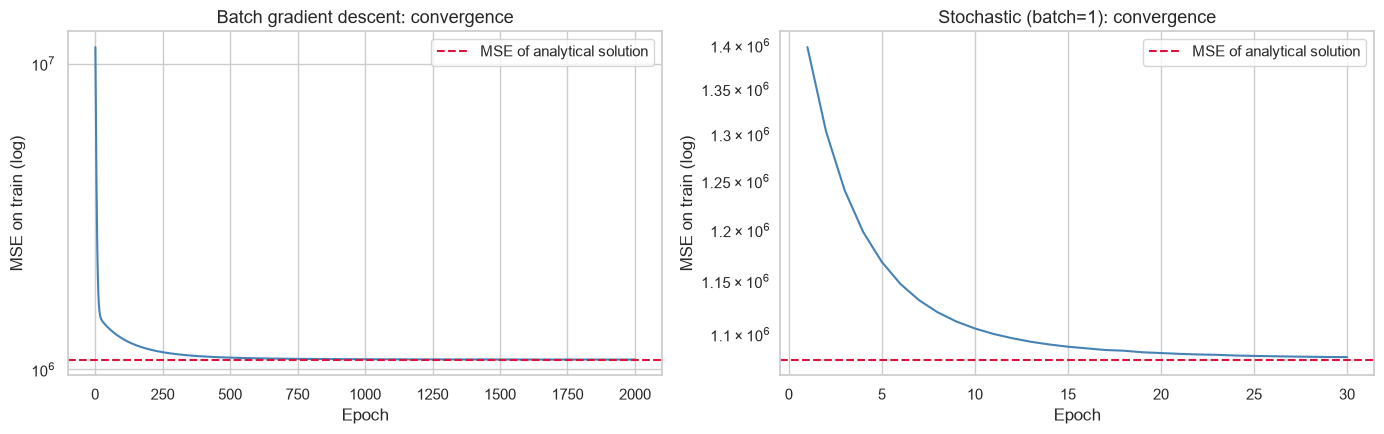

In [ ]:
# How the error decreased over epochs — both methods converged
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, solver, title in zip(axes, ["gd", "sgd"],
                             ["Batch gradient descent", "Stochastic (batch=1)"]):
    history = models_own[solver].loss_history_
    ax.plot(range(1, len(history) + 1), history, color="steelblue")
    ax.axhline(np.mean((y_train - models_own["analytic"].predict(X_train)) ** 2),
               color="crimson", ls="--", label="MSE of analytical solution")
    ax.set_yscale("log")
    ax.set_title(f"{title}: convergence")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE on train (log)")
    ax.legend()

plt.tight_layout()
plt.show()

**What the plots show.** Both curves level off at a plateau that matches the MSE of the analytical solution (the red line). This means that both gradient descent methods have actually reached the minimum rather than stopping prematurely.

SGD reaches this plateau within **30 epochs**, while batch gradient descent requires around **2,000 epochs**. The reason is that batch GD makes one parameter update per epoch using the entire dataset, whereas SGD makes **38,703 updates per epoch**, one for each training sample.


### 3.3. Comparison with `LinearRegression` from sklearn

In [41]:
# Reference: sklearn solves the same OLS problem 
# in closed form (via SVD), not with gradient descent.
sk_lr = LinearRegression().fit(X_train, y_train)

print("=== train ===")
compare("custom (SGD)", models_own["sgd"].predict(X_train),
        "sklearn", sk_lr.predict(X_train), y_train)
print("\n=== test ===")
compare("custom (SGD)", models_own["sgd"].predict(X_test),
        "sklearn", sk_lr.predict(X_test), y_test)
print("\n=== analytic solution vs sklearn (should match almost exactly) ===")
compare("custom (analytic)", models_own["analytic"].predict(X_test),
        "sklearn", sk_lr.predict(X_test), y_test)

=== train ===
  custom (SGD)           MAE   715.43   RMSE  1038.87   R2  0.5776
  sklearn                MAE   713.56   RMSE  1037.76   R2  0.5785
  MAE difference: 1.88 $  (0.26 %)

=== test ===
  custom (SGD)           MAE   709.55   RMSE  1026.08   R2  0.5858
  sklearn                MAE   708.55   RMSE  1025.99   R2  0.5859
  MAE difference: 1.00 $  (0.14 %)

=== analytic solution vs sklearn (should match almost exactly) ===
  custom (analytic)      MAE   708.55   RMSE  1025.99   R2  0.5859
  sklearn                MAE   708.55   RMSE  1025.99   R2  0.5859
  MAE difference: 0.00 $  (0.00 %)


In [42]:
# Weights comparison
weights = pd.DataFrame({
    "feature": ["intercept"] + feature_list,
    "custom (analytic)": models_own["analytic"].weights_,
    "custom (SGD)": models_own["sgd"].weights_,
    "sklearn": np.concatenate([[sk_lr.intercept_], sk_lr.coef_]),
}).set_index("feature")
weights["|analytic - sklearn|"] = (weights["custom (analytic)"] - weights["sklearn"]).abs()
print(weights.to_string())
print(f"\nmaximum deviation between analytic and sklearn: "
      f"{weights['|analytic - sklearn|'].max():.2e}")

                     custom (analytic)  custom (SGD)    sklearn  |analytic - sklearn|
feature                                                                              
intercept                     602.8165      637.2814   602.8165                0.0000
Elevator                    1,574.9629    1,544.7000 1,574.9629                0.0000
Hardwood Floors               464.3701      470.9454   464.3701                0.0000
Cats Allowed                  228.7076      220.1394   228.7076                0.0000
Dogs Allowed                 -177.9395     -162.2810  -177.9395                0.0000
Doorman                       -90.4629       -5.8511   -90.4629                0.0000
Dishwasher                    161.8650       69.6407   161.8650                0.0000
No Fee                        616.1982      601.5073   616.1982                0.0000
Laundry in Building           152.1101      146.3593   152.1101                0.0000
Fitness Center               -174.9434     -180.8133  

**The analytic solution agrees with `sklearn` to the tenth decimal place** — as expected, since both solve the same least-squares problem (sklearn via SVD, custom via the pseudoinverse).

**SGD deviates by less than 1% on all three metrics** — the nature of the method: after 30 epochs it halts in a small neighbourhood of the minimum.

**Individual SGD weights diverge more than the metrics**, due to the multicollinearity: correlated features admit a family of nearly equivalent weight vectors with identical predictive quality.

In [43]:
# add results to the summary tables
add_result("custom_linear_regression (SGD)",
           y_train, models_own["sgd"].predict(X_train),
           y_test, models_own["sgd"].predict(X_test))
add_result("custom_linear_regression (analytic)",
           y_train, models_own["analytic"].predict(X_train),
           y_test, models_own["analytic"].predict(X_test))
add_result("sklearn_linear_regression",
           y_train, sk_lr.predict(X_train), y_test, sk_lr.predict(X_test))

custom_linear_regression (SGD)       MAE   715.43 /   709.55   RMSE  1038.87 /  1026.08   R2  0.5776 /  0.5858
custom_linear_regression (analytic)  MAE   713.56 /   708.55   RMSE  1037.76 /  1025.99   R2  0.5785 /  0.5859
sklearn_linear_regression            MAE   713.56 /   708.55   RMSE  1037.76 /  1025.99   R2  0.5785 /  0.5859


## 4. Regularized models implementation — Ridge, Lasso, ElasticNet

### 4.1. Custom RegularizedLinearRegression

The regularization mechanics are already implemented in `CustomLinearRegression` through the `penalty` parameter — we'll add wrappers with descriptive names.

Since sklearn minimizes a specific objective, the regularization term must be scaled consistently — otherwise the weights will differ significantly.

| Model | Objective |
|---|---|
| `Ridge(alpha)` | $\|y - Xw\|_2^2 + \alpha \|w\|_2^2$|
| `Lasso(alpha)` | $\frac{1}{2n}\|y - Xw\|_2^2 + \alpha \|w\|_1$ |
| `ElasticNet(alpha, ρ)` | $\frac{1}{2n}\|y - Xw\|_2^2 + \alpha\rho\|w\|_1 + \frac{\alpha(1-\rho)}{2}\|w\|_2^2$ |

Custom GD minimizes **MSE**, that is, $\frac{1}{n}\|y - Xw\|^2$.

To reach the same optimum, the penalties must be rescaled into this normalization:

* **Ridge:** $\text{MSE} + \frac{\alpha}{n}\|w\|_2^2 \;\Rightarrow\;
  \nabla_{reg} = \frac{2\alpha}{n} w$
* **Lasso:** $\text{MSE} + 2\alpha\|w\|_1
  \;\Rightarrow\; \nabla_{reg} = 2\alpha\,\operatorname{sign}(w)$
* **ElasticNet:** $\nabla_{reg} = 2\alpha\big(\rho\operatorname{sign}w + (1-\rho) w\big)$

In [44]:
class CustomRidge(CustomLinearRegression):

    def __init__(self, alpha=1.0, **kwargs):
        super().__init__(penalty="l2", alpha=alpha, **kwargs)


class CustomLasso(CustomLinearRegression):

    def __init__(self, alpha=1.0, **kwargs):
        super().__init__(penalty="l1", alpha=alpha, **kwargs)


class CustomElasticNet(CustomLinearRegression):

    def __init__(self, alpha=1.0, l1_ratio=0.5, **kwargs):
        super().__init__(penalty="elastic", alpha=alpha, l1_ratio=l1_ratio, **kwargs)

### 4.2. Training, metrics, and comparison with sklearn

In [45]:
ALPHA = 1.0         

configs = [
    ("ridge", CustomRidge(alpha=ALPHA), Ridge(alpha=ALPHA)),
    ("lasso", CustomLasso(alpha=ALPHA), Lasso(alpha=ALPHA)),
    ("elastic_net", CustomElasticNet(alpha=ALPHA, l1_ratio=0.5),
     ElasticNet(alpha=ALPHA, l1_ratio=0.5))
]

fitted = {}
for name, custom_model, sk_model in configs:
    custom_model.fit(X_train, y_train)
    sk_model.fit(X_train, y_train)
    fitted[name] = (custom_model, sk_model)
    print(f"=== {name}, alpha={ALPHA} — test ===")
    compare("custom (SGD)", custom_model.predict(X_test),
            "sklearn", sk_model.predict(X_test), y_test)
    print()

=== ridge, alpha=1.0 — test ===
  custom (SGD)           MAE   709.55   RMSE  1026.08   R2  0.5858
  sklearn                MAE   708.55   RMSE  1025.99   R2  0.5859
  MAE difference: 1.00 $  (0.14 %)

=== lasso, alpha=1.0 — test ===
  custom (SGD)           MAE   709.40   RMSE  1026.17   R2  0.5857
  sklearn                MAE   707.95   RMSE  1025.74   R2  0.5861
  MAE difference: 1.45 $  (0.20 %)

=== elastic_net, alpha=1.0 — test ===
  custom (SGD)           MAE   796.64   RMSE  1172.09   R2  0.4596
  sklearn                MAE   796.20   RMSE  1177.04   R2  0.4550
  MAE difference: 0.44 $  (0.05 %)



In [46]:
for name, (custom_model, sk_model) in fitted.items():
    add_result(f"custom_{name}", y_train, custom_model.predict(X_train),
               y_test, custom_model.predict(X_test))
    add_result(f"sklearn_{name}", y_train, sk_model.predict(X_train),
               y_test, sk_model.predict(X_test))

custom_ridge                         MAE   715.43 /   709.55   RMSE  1038.87 /  1026.08   R2  0.5776 /  0.5858
sklearn_ridge                        MAE   713.55 /   708.55   RMSE  1037.76 /  1025.99   R2  0.5785 /  0.5859
custom_lasso                         MAE   715.38 /   709.40   RMSE  1039.22 /  1026.17   R2  0.5773 /  0.5857
sklearn_lasso                        MAE   713.09 /   707.95   RMSE  1037.96 /  1025.74   R2  0.5783 /  0.5861
custom_elastic_net                   MAE   810.70 /   796.64   RMSE  1188.68 /  1172.09   R2  0.4470 /  0.4596
sklearn_elastic_net                  MAE   810.03 /   796.20   RMSE  1193.39 /  1177.04   R2  0.4426 /  0.4550


**ElasticNet is noticeably worse than the rest** (MAE ≈ 796 vs ≈ 708). This is because it is not equivalent to Lasso or Ridge at the same alpha — its penalty is structured differently, and at `alpha=1, l1_ratio=0.5` in sklearn's normalization, the L1 component of the penalty is strong enough to shrink the weights substantially, which causes the model to underfit. The alpha tuning in Section 7 shows that this can be fixed.

### How regularization affects the weights

Let's verify on real data that **L1 zeroes out weights while L2 does not.**

In [ ]:
alphas = [0.1, 1, 10, 50, 100, 300, 1000]
rows = []
for a in alphas:
    ridge = Ridge(alpha=a).fit(X_train, y_train)
    lasso = Lasso(alpha=a).fit(X_train, y_train)
    rows.append({
        "alpha": a,
        "Ridge: Number of zero weights": int(np.sum(np.abs(ridge.coef_) < 1e-8)),
        "Lasso: Number of zero weights": int(np.sum(np.abs(lasso.coef_) < 1e-8)),
        "Ridge: R2 test": r2_score_custom(y_test, ridge.predict(X_test)),
        "Lasso: R2 test": r2_score_custom(y_test, lasso.predict(X_test)),
    })

zeros = pd.DataFrame(rows).set_index("alpha")
zeros

,Ridge: Number of zero weights,Lasso: Number of zero weights,Ridge: R2 test,Lasso: R2 test
alpha,,,,
0.1000,0,0,0.5859,0.5859
1.0000,0,0,0.5859,0.5861
10.0000,0,8,0.5859,0.5829
50.0000,0,18,0.5860,0.5633
100.0000,0,19,0.5861,0.5368
300.0000,0,20,0.5861,0.3416
"1,000.0000",0,22,0.5836,-0.0000


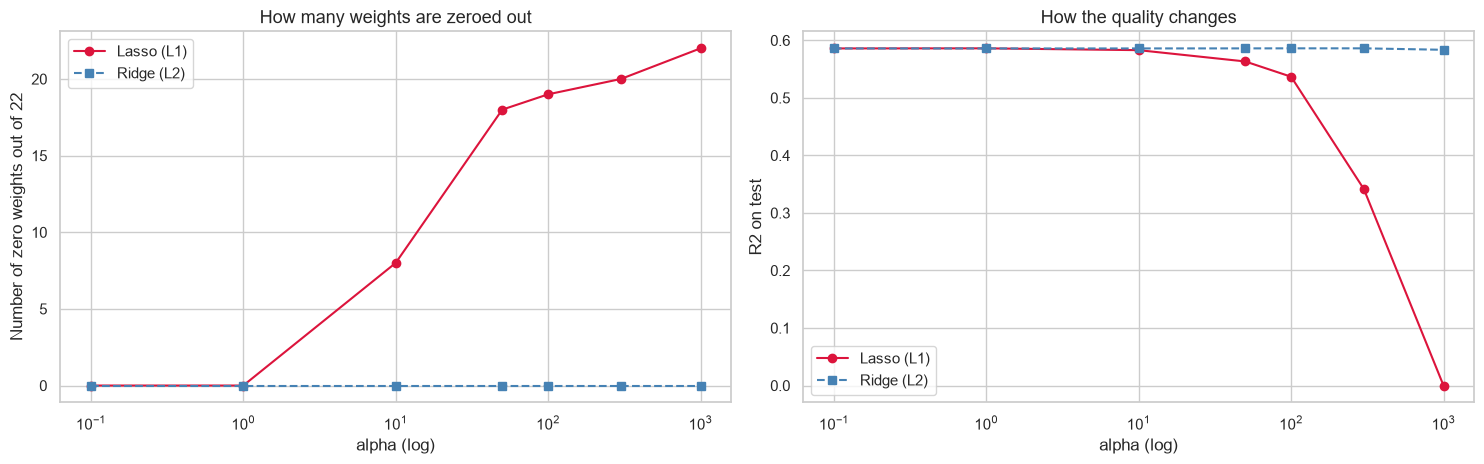

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

axes[0].plot(alphas, zeros["Lasso: Number of zero weights"], "o-", color="crimson", label="Lasso (L1)")
axes[0].plot(alphas, zeros["Ridge: Number of zero weights"], "s--", color="steelblue", label="Ridge (L2)")
axes[0].set_xscale("log")
axes[0].set_title("How many weights are zeroed out")
axes[0].set_xlabel("alpha (log)")
axes[0].set_ylabel("Number of zero weights out of 22")
axes[0].legend()

axes[1].plot(alphas, zeros["Lasso: R2 test"], "o-", color="crimson", label="Lasso (L1)")
axes[1].plot(alphas, zeros["Ridge: R2 test"], "s--", color="steelblue", label="Ridge (L2)")
axes[1].set_xscale("log")
axes[1].set_title("How the quality changes")
axes[1].set_xlabel("alpha (log)")
axes[1].set_ylabel("R2 on test")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Which features survive last under Lasso
lasso_strong = Lasso(alpha=100).fit(X_train, y_train)
survivors = pd.Series(lasso_strong.coef_, index=feature_list)
survivors = survivors[np.abs(survivors) > 1e-8].sort_values(key=abs, ascending=False)
print(f"With alpha=100, Lasso retained {len(survivors)} features out of 22:")
print(survivors.to_string())

При alpha=100 Lasso оставил 3 признаков из 22:
Elevator          1,243.6492
Hardwood Floors     452.7832
No Fee              386.2061


# Feature normalization

Examples of when feature normalization is mandatory / not required

**Mandatory:**
- Distance-based algorithms (KNN, K-Means clustering) — Euclidean distance is dominated by the feature that has the largest scale, effectively ignoring other features.
- Gradient-based optimization (linear/logistic regression, neural networks) — features with large scales cause disproportionately large gradients, making training unstable or requiring a very small learning rate.
- Regularized models (Ridge, Lasso) — the penalty $\lambda\|w\|$ unfairly penalizes features that need larger weights simply because their natural scale is small, distorting feature selection/shrinkage.

**Not required:**
- Tree-based models (Decision Trees, Random Forest, Gradient Boosting) — splits are based on thresholding a single feature at a time ($x_j > t$), so the relative scale between different features never enters the computation.

## MinMaxScaler

MinMaxScaler formula

$$
x' = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

where $x_{min}$ and $x_{max}$ are computed on the training set only and then reused to transform the test set.

### Custom

In [ ]:
class MinMaxScalerCustom:
    def fit(self, X):
        X = np.asarray(X)
        self.min_ = X.min(axis=0)
        self.max_ = X.max(axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X)
        return (X - self.min_) / (self.max_ - self.min_)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

### Built-in and Comparison

In [ ]:
scaler_custom = MinMaxScalerCustom()
X_train_scaled_custom = scaler_custom.fit_transform(X_train)
X_test_scaled_custom = scaler_custom.transform(X_test)

scaler_sklearn = MinMaxScaler()
X_train_scaled_sk = scaler_sklearn.fit_transform(X_train)
X_test_scaled_sk = scaler_sklearn.transform(X_test)

print(np.allclose(X_train_scaled_custom, X_train_scaled_sk))
print(np.allclose(X_test_scaled_custom, X_test_scaled_sk))

## StandardScaler

StandardScaler formula

$$
x' = \frac{x - \mu}{\sigma}
$$

where $\mu$ (mean) and $\sigma$ (standard deviation) are computed on the training set only, then reused to transform the test set. This centers the data to zero mean and unit variance.

### Custom

In [ ]:
class StandardScalerCustom:
    def fit(self, X):
        X = np.asarray(X)
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X)
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)

### Built-in and Comparison

In [ ]:
scaler_custom_std = StandardScalerCustom()
X_train_std_custom = scaler_custom_std.fit_transform(X_train)
X_test_std_custom = scaler_custom_std.transform(X_test)

scaler_sklearn_std = StandardScaler()
X_train_std_sk = scaler_sklearn_std.fit_transform(X_train)
X_test_std_sk = scaler_sklearn_std.transform(X_test)

print(np.allclose(X_train_std_custom, X_train_std_sk))
print(np.allclose(X_test_std_custom, X_test_std_sk))

# Fit models with normalized data

In [ ]:
numeric_cols = ['bathrooms', 'bedrooms']
binary_cols = [c for c in feature_list if c not in numeric_cols]

def scale_numeric_only(X_train_df, X_test_df, scaler_class):
    scaler = scaler_class()
    scaler.fit(X_train_df[numeric_cols])
    Xtr_num = scaler.transform(X_train_df[numeric_cols])
    Xte_num = scaler.transform(X_test_df[numeric_cols])
    Xtr = np.hstack([Xtr_num, X_train_df[binary_cols].values])
    Xte = np.hstack([Xte_num, X_test_df[binary_cols].values])
    return Xtr, Xte

X_train_mm, X_test_mm = scale_numeric_only(X_train, X_test, MinMaxScalerCustom)
X_train_std, X_test_std = scale_numeric_only(X_train, X_test, StandardScalerCustom)

scalers = {
    'MinMax': (X_train_mm, X_test_mm),
    'Standard': (X_train_std, X_test_std),
}

model_configs = [
    ('LinearRegression', 'l2', 0.0, LinearRegression()),
    ('Ridge', 'l2', 0.1, Ridge(alpha=0.1)),
    ('Lasso', 'l1', 0.1, Lasso(alpha=0.1)),
    ('ElasticNet', 'elasticnet', 0.1, ElasticNet(alpha=0.1, l1_ratio=0.5)),
]

for scaler_name, (Xtr_s, Xte_s) in scalers.items():
    for model_name, penalty, alpha, sk_model in model_configs:
        if model_name == 'LinearRegression':
            custom = LinearRegressionSGD(lr = 0.0001, n_epochs=50, random_state=21)
        else:
            custom = RegularizedLinearRegressionSGD(lr=0.0001, n_epochs=50, alpha=alpha,
                                                      l1_ratio=0.5, penalty=penalty, random_state=21)
        custom.fit(Xtr_s, y_train)
        yp_tr, yp_te = custom.predict(Xtr_s), custom.predict(Xte_s)

        sk_model.fit(Xtr_s, y_train)
        yp_tr_sk, yp_te_sk = sk_model.predict(Xtr_s), sk_model.predict(Xte_s)

        for label, ytr, yte in [(f'{model_name} ({scaler_name}, custom)', yp_tr, yp_te),
                                  (f'{model_name} ({scaler_name}, sklearn)', yp_tr_sk, yp_te_sk)]:
            mae_table.loc[len(mae_table)] = [label, mean_absolute_error(y_train, ytr), mean_absolute_error(y_test, yte)]
            rmse_table.loc[len(rmse_table)] = [label, root_mean_squared_error(y_train, ytr), root_mean_squared_error(y_test, yte)]
            r2_table.loc[len(r2_table)] = [label, r2_score_custom(y_train, ytr), r2_score_custom(y_test, yte)]

# Native

In [ ]:
mean_pred_train = np.full_like(y_train, y_train.mean(), dtype=float)
mean_pred_test = np.full_like(y_test, y_train.mean(), dtype=float)    

median_pred_train = np.full_like(y_train, y_train.median(), dtype=float)
median_pred_test = np.full_like(y_test, y_train.median(), dtype=float)

for label, ytr_pred, yte_pred in [('Mean baseline', mean_pred_train, mean_pred_test),
                                    ('Median baseline', median_pred_train, median_pred_test)]:
    mae_table.loc[len(mae_table)] = [label, mean_absolute_error(y_train, ytr_pred), mean_absolute_error(y_test, yte_pred)]
    rmse_table.loc[len(rmse_table)] = [label, root_mean_squared_error(y_train, ytr_pred), root_mean_squared_error(y_test, yte_pred)]
    r2_table.loc[len(r2_table)] = [label, r2_score_custom(y_train, ytr_pred), r2_score_custom(y_test, yte_pred)]

# Compare Results

In [ ]:
mae_table

In [ ]:
rmse_table

In [ ]:
r2_table

**Best model:** the model with the lowest test error while maintaining a small train/test gap — favoring generalization over merely fitting the training data well.

**Most stable model:** the model with the smallest gap between train and test metrics (lowest variance), regardless of the absolute error level — this reflects how consistently the model performs on unseen data.

Overall, `LinearRegression` and `Lasso` (on unscaled features) performed best, achieving the highest test R² (~0.586) with a small train/test gap.